## C1 - WEEK 1

- Adrià Cantarero Carreras
- Ivan Martin Campoy (1673246@uab.cat)
- Irene Pumares Benaiges (1810704@uab.cat)
- Lavish Ramchandani (1691238@uab.cat)

In [1]:
#needed libraries

import os
import re
import cv2
import pickle
import numpy as np

## TASK 1: Compute image descriptors

In [ ]:
#database and qsd1 paths

bbdd_path = "./BBDD"
qsd1_path = "./qsd1_w1"

COLOR_SPACES = {
    "GRAY": cv2.COLOR_BGR2GRAY,
    "RGB":  cv2.COLOR_BGR2RGB,
    "HSV":  cv2.COLOR_BGR2HSV,
    "LAB":  cv2.COLOR_BGR2LAB,
    "YCRCB": cv2.COLOR_BGR2YCrCb,
}

#value range of every channel. OpenCV hue goes from 0 to 179, not to 255
CHANNEL_RANGES = {
    "GRAY":  [(0, 256)],
    "RGB":   [(0, 256)] * 3,
    "HSV":   [(0, 180), (0, 256), (0, 256)],
    "LAB":   [(0, 256)] * 3,
    "YCRCB": [(0, 256)] * 3,
}

#descriptors
bbdd_descriptors = []
qsd1_descriptors = []


#----------------------------------------------------------------------------------
#sort files
def return_number(string):
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', string)]

#sort bbdd files
bbdd_files = [f for f in os.listdir(bbdd_path) if f.lower().endswith(".jpg")]
bbdd_files.sort(key=return_number)

#sort qsd1 files
qsd1_files = [f for f in os.listdir(qsd1_path) if f.lower().endswith(".jpg")]
qsd1_files.sort(key=return_number)

#id of an image = number in its file name (bbdd_00007.jpg -> 7)
def image_id(file_name):
    return int(re.findall(r'\d+', file_name)[-1])

bbdd_ids = np.array([image_id(f) for f in bbdd_files])
qsd1_ids = np.array([image_id(f) for f in qsd1_files])
#----------------------------------------------------------------------------------

#feature extraction function

def compute_1d_Histogram(image, color_space = "HSV", bins = 32):
    if color_space in COLOR_SPACES:
        img_converted = cv2.cvtColor(image, COLOR_SPACES[color_space])
    else:
        img_converted = image #in case it is already in BGR

    ranges = CHANNEL_RANGES.get(color_space, [(0, 256)] * 3)

    #calc hist
    if len(img_converted.shape) == 2: #grayscale
        hist = cv2.calcHist([img_converted], [0], None, [bins], list(ranges[0]))
        descriptor = hist.flatten() #convert to 1D array
        #normalize hisotogram
        total = np.sum(hist)
        if total > 0:
            hist = hist / total
        descriptor = hist

    elif len(img_converted.shape) == 3:
        channel_hists = []

        for channel in range(3):
            ch_hist = cv2.calcHist([img_converted], [channel], None, [bins], list(ranges[channel]))
            ch_hist = ch_hist.flatten()

            #normalize each channel 
            total = np.sum(ch_hist)
            if total > 0:
                ch_hist = ch_hist / total

            channel_hists.append(ch_hist)

        descriptor = np.concatenate(channel_hists) #stack all the channels into 1D array

    #normalization
    total_pixels = np.sum(descriptor)
    if total_pixels > 0:
        descriptor = descriptor / total_pixels

    return descriptor

#----------------------------------------------------------------------------------

#read one image
def read_image(img_path):
    image = cv2.imread(img_path)
    if image is None:
        raise IOError(f"Could not read {img_path}")   #skipping it would shift every index after it and break the ground truth
    return image

#load images iteratively bbdd set
bbdd_imgs = []
for file_name in bbdd_files:
    img_path = os.path.join(bbdd_path, file_name)
    image = read_image(img_path)
    bbdd_imgs.append(image)

##load images iteratively qsd1 set
qsd1_imgs = []
for file_name in qsd1_files:
    img_path = os.path.join(qsd1_path, file_name)
    image = read_image(img_path)
    qsd1_imgs.append(image)

In [18]:
#comparison

#METHOD 1: Grayscale
bbdd_desc_m1 = [compute_1d_Histogram(im, color_space="GRAY", bins=32) for im in bbdd_imgs]
qsd1_desc_m1 = [compute_1d_Histogram(im, color_space="GRAY", bins=32) for im in qsd1_imgs]

bbdd_desc_m1 = np.array(bbdd_desc_m1)  #shape: (287, 32)
qsd1_desc_m1 = np.array(qsd1_desc_m1)  #shape: (30, 32)

print(f" Shape of bbdd_desc_m1: {bbdd_desc_m1.shape}")
print(f" Shape of qsd1_desc_m1: {qsd1_desc_m1.shape}\n")

#METHOD 2: HSV
bbdd_desc_m2 = [compute_1d_Histogram(im, color_space="HSV", bins=32) for im in bbdd_imgs]
qsd1_desc_m2 = [compute_1d_Histogram(im, color_space="HSV", bins=32) for im in qsd1_imgs]

bbdd_desc_m2 = np.array(bbdd_desc_m2)  #shape: (287, 96)
qsd1_desc_m2 = np.array(qsd1_desc_m2)  #shape: (30, 96)

print(f" Shape of bbdd_desc_m2: {bbdd_desc_m2.shape}")
print(f" Shape of qsd1_desc_m2: {qsd1_desc_m2.shape}")


#EXTRA METHODS
from utils.extra_descriptors import *

#METHOD 3: Chroma only, LAB (a + b channels, no lightness)
bbdd_desc_m3 = [hist_chroma(im, color_space="LAB", bins=32) for im in bbdd_imgs]
qsd1_desc_m3 = [hist_chroma(im, color_space="LAB", bins=32) for im in qsd1_imgs]

bbdd_desc_m3 = np.array(bbdd_desc_m3)  #shape: (287, 64)
qsd1_desc_m3 = np.array(qsd1_desc_m3)  #shape: (30, 64)

print(f" Shape of bbdd_desc_m3: {bbdd_desc_m3.shape}")
print(f" Shape of qsd1_desc_m3: {qsd1_desc_m3.shape}\n")

#METHOD 4: Chroma only, HSV (H + S channels, no value)
bbdd_desc_m4 = [hist_chroma(im, color_space="HSV", bins=32) for im in bbdd_imgs]
qsd1_desc_m4 = [hist_chroma(im, color_space="HSV", bins=32) for im in qsd1_imgs]

bbdd_desc_m4 = np.array(bbdd_desc_m4)  #shape: (287, 64)
qsd1_desc_m4 = np.array(qsd1_desc_m4)  #shape: (30, 64)

print(f" Shape of bbdd_desc_m4: {bbdd_desc_m4.shape}")
print(f" Shape of qsd1_desc_m4: {qsd1_desc_m4.shape}\n")

#METHOD 5: CLAHE on lightness + LAB histogram
bbdd_desc_m5 = [hist_clahe_lab(im, bins=32) for im in bbdd_imgs]
qsd1_desc_m5 = [hist_clahe_lab(im, bins=32) for im in qsd1_imgs]

bbdd_desc_m5 = np.array(bbdd_desc_m5)  #shape: (287, 96)
qsd1_desc_m5 = np.array(qsd1_desc_m5)  #shape: (30, 96)

print(f" Shape of bbdd_desc_m5: {bbdd_desc_m5.shape}")
print(f" Shape of qsd1_desc_m5: {qsd1_desc_m5.shape}\n")

#METHOD 6: Saturation-weighted hue histogram
bbdd_desc_m6 = [hist_hue_weighted(im, bins=36) for im in bbdd_imgs]
qsd1_desc_m6 = [hist_hue_weighted(im, bins=36) for im in qsd1_imgs]

bbdd_desc_m6 = np.array(bbdd_desc_m6)  #shape: (287, 36)
qsd1_desc_m6 = np.array(qsd1_desc_m6)  #shape: (30, 36)

print(f" Shape of bbdd_desc_m6: {bbdd_desc_m6.shape}")
print(f" Shape of qsd1_desc_m6: {qsd1_desc_m6.shape}\n")

#METHOD 7: Gradient orientation histogram
bbdd_desc_m7 = [hist_gradient_orientation(im, bins=18) for im in bbdd_imgs]
qsd1_desc_m7 = [hist_gradient_orientation(im, bins=18) for im in qsd1_imgs]

bbdd_desc_m7 = np.array(bbdd_desc_m7)  #shape: (287, 18)
qsd1_desc_m7 = np.array(qsd1_desc_m7)  #shape: (30, 18)

print(f" Shape of bbdd_desc_m7: {bbdd_desc_m7.shape}")
print(f" Shape of qsd1_desc_m7: {qsd1_desc_m7.shape}\n")

#METHOD 8: Global LBP histogram
bbdd_desc_m8 = [hist_lbp(im) for im in bbdd_imgs]
qsd1_desc_m8 = [hist_lbp(im) for im in qsd1_imgs]

bbdd_desc_m8 = np.array(bbdd_desc_m8)  #shape: (287, 256)
qsd1_desc_m8 = np.array(qsd1_desc_m8)  #shape: (30, 256)

print(f" Shape of bbdd_desc_m8: {bbdd_desc_m8.shape}")
print(f" Shape of qsd1_desc_m8: {qsd1_desc_m8.shape}")

 Shape of bbdd_desc_m1: (287, 32)
 Shape of qsd1_desc_m1: (30, 32)

 Shape of bbdd_desc_m2: (287, 96)
 Shape of qsd1_desc_m2: (30, 96)
 Shape of bbdd_desc_m3: (287, 64)
 Shape of qsd1_desc_m3: (30, 64)

 Shape of bbdd_desc_m4: (287, 64)
 Shape of qsd1_desc_m4: (30, 64)

 Shape of bbdd_desc_m5: (287, 96)
 Shape of qsd1_desc_m5: (30, 96)

 Shape of bbdd_desc_m6: (287, 36)
 Shape of qsd1_desc_m6: (30, 36)

 Shape of bbdd_desc_m7: (287, 18)
 Shape of qsd1_desc_m7: (30, 18)

 Shape of bbdd_desc_m8: (287, 256)
 Shape of qsd1_desc_m8: (30, 256)


- - -
## Task 2: Similarity measures
- - -

In [19]:
eps = 1e-10  # small value to avoid division by zero


def euclidean_distance(x, y):
    return np.sqrt(np.sum((x - y) ** 2, axis=-1))

def L1_distance(x, y):
    return np.sum(np.abs(x - y), axis=-1)

def chi_squared_distance(x, y):
    return 0.5 * np.sum(((x - y) ** 2) / (x + y + eps), axis=-1)

def jensen_shannon_distance(x, y):
    m = 0.5 * (x + y)
    kl_x = np.sum(x * np.log((x + eps) / (m + eps)), axis=-1)
    kl_y = np.sum(y * np.log((y + eps) / (m + eps)), axis=-1)
    return np.sqrt(np.clip(0.5 * (kl_x + kl_y), 0, None))

def emd_distance(x, y, bins):
    n_hist = x.shape[-1] // bins
    cx = np.cumsum(x.reshape(x.shape[:-1] + (n_hist, bins)), axis=-1)
    cy = np.cumsum(y.reshape(y.shape[:-1] + (n_hist, bins)), axis=-1)
    return np.sum(np.abs(cx - cy), axis=(-2, -1))

#all the measures below are written as distances (smaller = more similar) because the retrieval step will rank every measure 
#with the same rule (sort ascending and take the first k)

def histogram_intersection_distance(x, y):
    return 1.0 - np.sum(np.minimum(x, y), axis=-1)

def hellinger_distance(x, y):
    return (1.0 / np.sqrt(2.0)) * np.sqrt(np.sum((np.sqrt(np.clip(x, 0, None)) - np.sqrt(np.clip(y, 0, None))) ** 2, axis=-1))

def cosine_distance(x, y):
    return 1.0 - np.sum(x * y, axis=-1) / (np.linalg.norm(x, axis=-1) * np.linalg.norm(y, axis=-1) + eps)

def correlation_distance(x, y):
    xc = x - np.mean(x, axis=-1, keepdims=True)
    yc = y - np.mean(y, axis=-1, keepdims=True)
    return 1.0 - np.sum(xc * yc, axis=-1) / (np.linalg.norm(xc, axis=-1) * np.linalg.norm(yc, axis=-1) + eps)

MEASURES = {
    "euclidean":      euclidean_distance,
    "L1":             L1_distance,
    "chi2":           chi_squared_distance,
    "intersection":   histogram_intersection_distance,
    "hellinger":      hellinger_distance,
    "cosine":         cosine_distance,
    "correlation":    correlation_distance,
    "jensen_shannon": jensen_shannon_distance,
    "emd":            emd_distance,
}

- - -
## Task 3: For each image in QSD1, evaluate all descriptor and distance combinations

For each QSD1 query, rank BBDD images using each descriptor-distance pair. Compare methods with MAP@1 and MAP@5, and retain each query's top-five IDs and AP scores. EMD uses the bin count associated with each descriptor.
- - -

In [ ]:
# import ml_metrics as metrics #Couldn't install it so I copied the code from the git

import numpy as np

#code from https://github.com/benhamner/Metrics/blob/master/Python/ml_metrics/custom/kdd_average_precision.py
def kdd_apk(actual, predicted, k=10):
    """
    Computes the average precision at k for Track 1 of the 2012 KDD Cup.

    This modified version uses the number of actual clicks as the denominator,
    regardless of k.

    This function computes the average prescision at k between two lists of
    items.

    Parameters
    ----------
    actual : list
             A list of elements that are to be predicted (order doesn't matter)
    predicted : list
                A list of predicted elements (order does matter)
    k : int, optional
        The maximum number of predicted elements

    Returns
    -------
    score : double
            The average precision at k over the input lists

    """
    if len(predicted)>k:
        predicted = predicted[:k]

    score = 0.0
    num_hits = 0.0

    for i,p in enumerate(predicted):
        if p in actual and p not in predicted[:i]: #p not in predicted[:i] is to avoid no extra marks for repeating
            num_hits += 1.0
            score += num_hits / (i+1.0)

    if not actual:
        return 0.0

    return score / len(actual)

def kdd_mapk(actual, predicted, k=10):
    """
    Computes the mean average precision at k for Track 1 of the 2012 KDD Cup.

    This modified version uses the number of actual clicks as the denominator,
    regardless of k.

    This function computes the mean average prescision at k between two lists
    of lists of items.

    Parameters
    ----------
    actual : list
             A list of lists of elements that are to be predicted 
             (order doesn't matter in the lists)
    predicted : list
                A list of lists of predicted elements
                (order matters in the lists)
    k : int, optional
        The maximum number of predicted elements

    Returns
    -------
    score : double
            The mean average precision at k over the input lists

    """
    return np.mean([kdd_apk(a,p,k) for a,p in zip(actual, predicted)])


#apk is like the average precision of hits at k items
#but mapk looks in the entire dataset

In [21]:
import pandas as pd
from IPython.display import display

gt_path = os.path.join(qsd1_path, "gt_corresps.pkl") #ground truth correspondences

with open(gt_path, "rb") as f:
    gt_corresps = pickle.load(f)

# Descriptor-specific EMD bin counts: one histogram is split for each channel.
descriptor_sets = {
    "M1 Grayscale": (bbdd_desc_m1, qsd1_desc_m1, 32),
    "M2 HSV": (bbdd_desc_m2, qsd1_desc_m2, 32),
    "M3 LAB chroma": (bbdd_desc_m3, qsd1_desc_m3, 32),
    "M4 HSV chroma": (bbdd_desc_m4, qsd1_desc_m4, 32),
    "M5 CLAHE LAB": (bbdd_desc_m5, qsd1_desc_m5, 32),
    "M6 Weighted hue": (bbdd_desc_m6, qsd1_desc_m6, 36),
    "M7 Gradient orientation": (bbdd_desc_m7, qsd1_desc_m7, 18),
    "M8 LBP": (bbdd_desc_m8, qsd1_desc_m8, 256),
}

# Verify that each query, descriptor array, and ground-truth entry lines up.
num_queries = len(gt_corresps)
assert num_queries == len(qsd1_files), (
    f"GT has {num_queries} entries but QSD1 has {len(qsd1_files)} images."
)
assert len(bbdd_ids) == len(bbdd_files), "BBDD IDs do not match the database files."

actual_ids = [[int(item) for item in query_gt] for query_gt in gt_corresps]
summary_rows = []
per_query_rows = []
experiment_predictions = {}

for descriptor_name, (database_descriptors, query_descriptors, emd_bins) in descriptor_sets.items():
    assert len(database_descriptors) == len(bbdd_ids)
    assert len(query_descriptors) == num_queries

    for measure_name, measure in MEASURES.items():
        predictions = []

        for query_index, query_descriptor in enumerate(query_descriptors):
            if measure_name == "emd":
                distances = measure(query_descriptor, database_descriptors, bins=emd_bins)
            else:
                distances = measure(query_descriptor, database_descriptors)

            top_indices = np.argsort(distances)[:5]
            top5_ids = [int(image_id) for image_id in bbdd_ids[top_indices]]
            predictions.append(top5_ids)

            query_gt = actual_ids[query_index]
            per_query_rows.append({
                "Descriptor": descriptor_name,
                "Distance": measure_name,
                "Query": qsd1_files[query_index],
                "GT IDs": query_gt,
                "Top 1 ID": top5_ids[0],
                "Top 5 IDs": top5_ids,
                "AP@1": kdd_apk(query_gt, top5_ids[:1], k=1),
                "AP@5": kdd_apk(query_gt, top5_ids, k=5),
            })

        experiment_predictions[(descriptor_name, measure_name)] = predictions
        summary_rows.append({
            "Descriptor": descriptor_name,
            "Distance": measure_name,
            "Method": f"{descriptor_name} + {measure_name}",
            "MAP@1": kdd_mapk(actual_ids, [items[:1] for items in predictions], k=1),
            "MAP@5": kdd_mapk(actual_ids, predictions, k=5),
        })

leaderboard = (
    pd.DataFrame(summary_rows)
    .sort_values(["MAP@5", "MAP@1"], ascending=False)
    .reset_index(drop=True)
)
leaderboard.insert(0, "Rank", np.arange(1, len(leaderboard) + 1))
per_query_results = pd.DataFrame(per_query_rows)
best_two_methods = leaderboard.head(2).copy()
best_two_map_table = best_two_methods[["Descriptor", "Distance", "MAP@1", "MAP@5"]].copy()
best_two_method_names = set(best_two_methods["Method"])
best_two_query_results = per_query_results[
    (per_query_results["Descriptor"] + " + " + per_query_results["Distance"]).isin(best_two_method_names)
].copy()

assert len(leaderboard) == len(descriptor_sets) * len(MEASURES)
assert len(per_query_results) == num_queries * len(descriptor_sets) * len(MEASURES)
assert leaderboard[["MAP@1", "MAP@5"]].ge(0).all().all()
assert leaderboard[["MAP@1", "MAP@5"]].le(1).all().all()

print(f"Evaluated {len(leaderboard)} methods over {num_queries} queries.")

print("Best two methods:")
display(best_two_map_table.round({"MAP@1": 4, "MAP@5": 4}))



Evaluated 72 methods over 30 queries.
Best two methods:


,Descriptor,Distance,MAP@1,MAP@5
0,M5 CLAHE LAB,L1,0.6,0.6611
1,M5 CLAHE LAB,intersection,0.6,0.6611


In [15]:
# Save complete experiment outputs so every method/query result is available after the kernel closes.
results_dir = "./results"
os.makedirs(results_dir, exist_ok=True)
leaderboard.to_csv(os.path.join(results_dir, "map_at_1_5_leaderboard.csv"), index=False)
per_query_results.to_csv(os.path.join(results_dir, "all_query_retrieval_results.csv"), index=False)
best_two_query_results.to_csv(os.path.join(results_dir, "best_two_methods_per_query.csv"), index=False)

print(f"Saved full leaderboard ({len(leaderboard)} rows) and per-query results ({len(per_query_results)} rows) to {results_dir}/")

Saved full leaderboard (72 rows) and per-query results (2160 rows) to ./results/


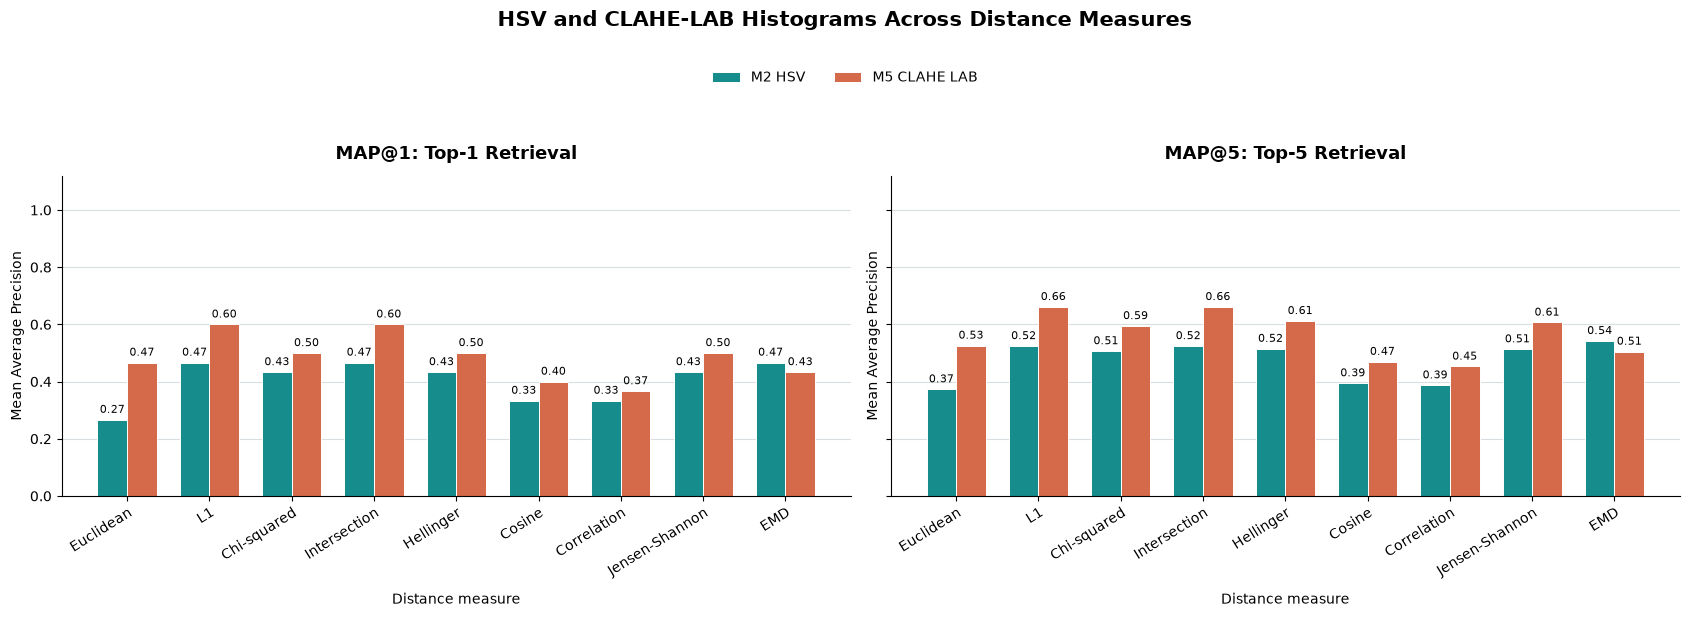

In [13]:
import matplotlib.pyplot as plt

chart_descriptors = ["M2 HSV", "M5 CLAHE LAB"]
distance_order = list(MEASURES.keys())
distance_labels = {
    "euclidean": "Euclidean",
    "L1": "L1",
    "chi2": "Chi-squared",
    "intersection": "Intersection",
    "hellinger": "Hellinger",
    "cosine": "Cosine",
    "correlation": "Correlation",
    "jensen_shannon": "Jensen-Shannon",
    "emd": "EMD",
}
chart_colors = {"M2 HSV": "#168C8C", "M5 CLAHE LAB": "#D56A4A"}

chart_results = leaderboard[leaderboard["Descriptor"].isin(chart_descriptors)]
assert len(chart_results) == len(chart_descriptors) * len(distance_order)

positions = np.arange(len(distance_order))
bar_width = 0.36
fig, axes = plt.subplots(1, 2, figsize=(17, 6), sharey=True)

for axis, metric, title in zip(
    axes,
    ["MAP@1", "MAP@5"],
    ["MAP@1: Top-1 Retrieval", "MAP@5: Top-5 Retrieval"],
):
    metric_table = (
        chart_results.pivot(index="Distance", columns="Descriptor", values=metric)
        .reindex(distance_order)
    )

    for descriptor_index, descriptor in enumerate(chart_descriptors):
        offset = (descriptor_index - 0.5) * bar_width
        bars = axis.bar(
            positions + offset,
            metric_table[descriptor].to_numpy(),
            width=bar_width,
            label=descriptor,
            color=chart_colors[descriptor],
            edgecolor="white",
            linewidth=0.7,
        )
        axis.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)

    axis.set_title(title, fontsize=13, fontweight="bold", pad=12)
    axis.set_xlabel("Distance measure", labelpad=10)
    axis.set_xticks(positions)
    axis.set_xticklabels(
        [distance_labels[name] for name in distance_order],
        rotation=32,
        ha="right",
        rotation_mode="anchor",
    )
    axis.set_ylim(0, 1.12)
    axis.set_yticks(np.linspace(0, 1, 6))
    axis.set_ylabel("Mean Average Precision")
    axis.set_axisbelow(True)
    axis.grid(axis="y", color="#D9DEE3", linewidth=0.8)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.94), ncol=2, frameon=False)
fig.suptitle(
    "HSV and CLAHE-LAB Histograms Across Distance Measures",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

- - -
## Task 4: Function to evaluate the best method on a blind test dataset

In [14]:
qst1_path = "./qst1_w1"
qst1_output_path = "./results/qst1_w1_results.pkl"


def generate_qst1_predictions(test_dir=qst1_path, output_path=qst1_output_path):
    """Create one rank-ordered list of top-10 BBDD IDs per naturally sorted QST1 query."""
    query_files = [
        file_name for file_name in os.listdir(test_dir)
        if file_name.lower().endswith(".jpg")
    ]
    query_files.sort(key=return_number)
    if not query_files:
        raise FileNotFoundError(f"No .jpg query images found in {test_dir}")
    if len(bbdd_ids) < 10:
        raise ValueError(f"Top-10 retrieval requires at least 10 BBDD images; found {len(bbdd_ids)}")

    query_images = [read_image(os.path.join(test_dir, file_name)) for file_name in query_files]
    query_descriptors = np.asarray([hist_clahe_lab(image, bins=32) for image in query_images])
    predictions = retrieve_topk(
        query_descriptors,
        bbdd_desc_m5,
        bbdd_ids,
        MEASURES["L1"],
        k=10,
    )

    assert len(predictions) == len(query_files)
    assert all(len(query_results) == 10 for query_results in predictions)
    assert all(type(image_id) is int for query_results in predictions for image_id in query_results)
    save_results(predictions, output_path)

    print(
        f"Saved {len(predictions)} queries with 10 integer BBDD IDs each "
        f"using CLAHE-LAB + L1 to {output_path}"
    )
    return predictions


qst1_predictions = generate_qst1_predictions()
print("First three query results:", qst1_predictions[:3])

Saved 30 queries with 10 integer BBDD IDs each using CLAHE-LAB + L1 to ./results/qst1_w1_results.pkl
First three query results: [[27, 276, 4, 259, 149, 51, 174, 239, 82, 235], [272, 182, 222, 47, 226, 79, 148, 97, 117, 212], [155, 45, 281, 253, 132, 88, 223, 144, 140, 215]]
